Titanic Dataset — Data Analytics

Section 1: Python Analytics & Visualization Tasks

Data Understanding & Cleaning
- What is the structure and shape of the dataset?
- What are the data types of each column?
- Which columns have missing values, and how can they be imputed?
- Are there any outliers (Age, Fare)? If yes, how do we treat them?


In [1]:
import pandas as pd

In [2]:
Titanic = pd.read_csv("Titanic-Dataset.csv")

In [3]:
Titanic.shape

(891, 12)

In [4]:
Titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
Titanic.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [6]:
Titanic.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [7]:
Titanic['Age'] = Titanic['Age'].fillna(Titanic['Age'].median())

In [8]:
Titanic['Embarked'] = Titanic['Embarked'].fillna(Titanic['Embarked'].mode()[0])

In [9]:
Titanic['Cabin Available'] = Titanic['Cabin'].notna().astype(int)
Titanic.drop(columns=['Cabin'], inplace=True)

In [10]:
Titanic.isnull().sum()

PassengerId        0
Survived           0
Pclass             0
Name               0
Sex                0
Age                0
SibSp              0
Parch              0
Ticket             0
Fare               0
Embarked           0
Cabin Available    0
dtype: int64

Exploratory Data Analysis
- What is the overall distribution of survivors vs non-survivors?

In [11]:
counts = Titanic['Survived'].value_counts()
counts

Survived
0    549
1    342
Name: count, dtype: int64

In [12]:
Percentage = Titanic['Survived'].value_counts(normalize=True)*100
Percentage

Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64

In [13]:
import matplotlib.pyplot as plt

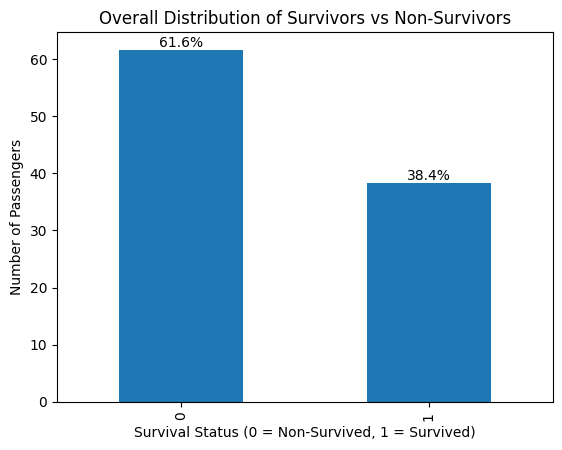

In [14]:
Percentage.plot(kind='bar')
plt.xlabel('Survival Status (0 = Non-Survived, 1 = Survived)')
plt.ylabel('Number of Passengers')
plt.title('Overall Distribution of Survivors vs Non-Survivors')

# Add percentage labels on bars
for i, value in enumerate(Percentage.values):
    plt.text(i, value, f'{value:.1f}%', ha='center', va='bottom') 
    
plt.show()

- How does survival differ by gender?

In [15]:
group_gender = Titanic.groupby('Sex')['Survived'].count()
group_gender

Sex
female    314
male      577
Name: Survived, dtype: int64

In [16]:
Percentage_gender_survived = Titanic.groupby('Sex')['Survived'].mean()*100
Percentage_gender_survived

Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64

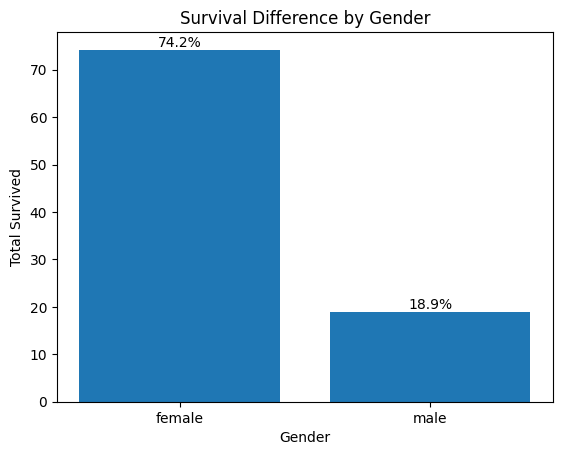

In [17]:
plt.bar(Percentage_gender_survived.index, Percentage_gender_survived.values)
plt.xlabel('Gender')
plt.ylabel('Total Survived')
plt.title('Survival Difference by Gender')

for i, value in enumerate(Percentage_gender_survived.values):
    plt.text(i, value, f'{value:.1f}%', ha='center', va='bottom')
plt.show()

- How does survival vary across passenger classes?

In [18]:
passenger_cls_survival = Titanic.groupby('Pclass')['Survived'].mean()*100
passenger_cls_survival

Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64

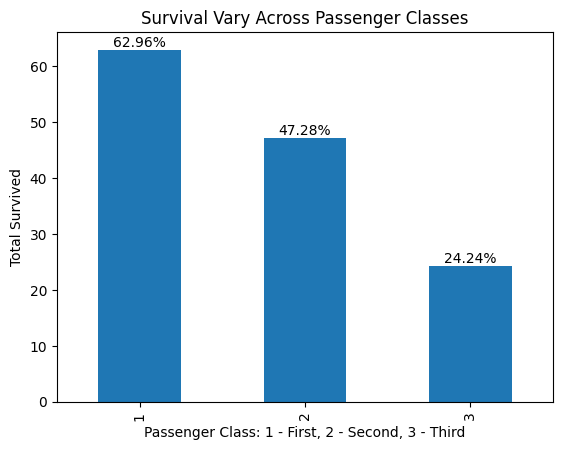

In [19]:
passenger_cls_survival.plot(kind='bar')
plt.xlabel('Passenger Class: 1 - First, 2 - Second, 3 - Third')
plt.ylabel('Total Survived')
plt.title('Survival Vary Across Passenger Classes')

for i, value in enumerate(passenger_cls_survival.values):
    plt.text(i, value, f'{value:.2f}%', ha = 'center', va = 'bottom')

plt.show()

- How is the Age distributed among all passengers?

In [20]:
Titanic['Age'].describe()

count    891.000000
mean      29.361582
std       13.019697
min        0.420000
25%       22.000000
50%       28.000000
75%       35.000000
max       80.000000
Name: Age, dtype: float64

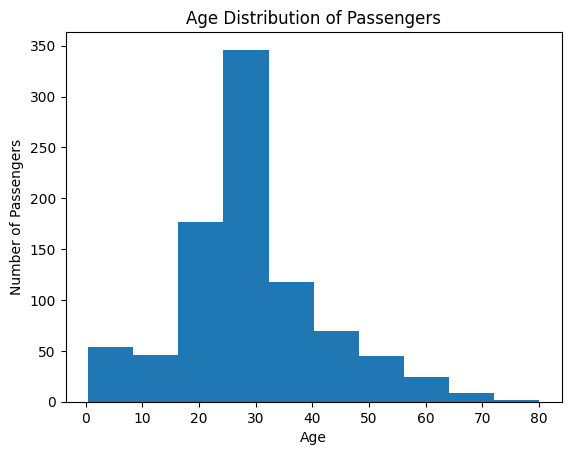

In [21]:
Titanic['Age'].plot(kind='hist')
plt.xlabel('Age')
plt.ylabel('Number of Passengers')
plt.title('Age Distribution of Passengers')
plt.show()
# bins
# Divides the Age range into 30 equal intervals (bins)
# Each bin counts how many passengers fall into that age range
# Example:
# Bin 0–3 → infants
# Bin 20–30 → young adults
# Bin 60–70 → elderly passengers

- Compare Age distributions between survivors and non-survivors.

In [22]:
Age_survived = Titanic[Titanic['Survived'] == 1]['Age']

In [23]:
Age_not_survived = Titanic[Titanic['Survived'] == 0]['Age']

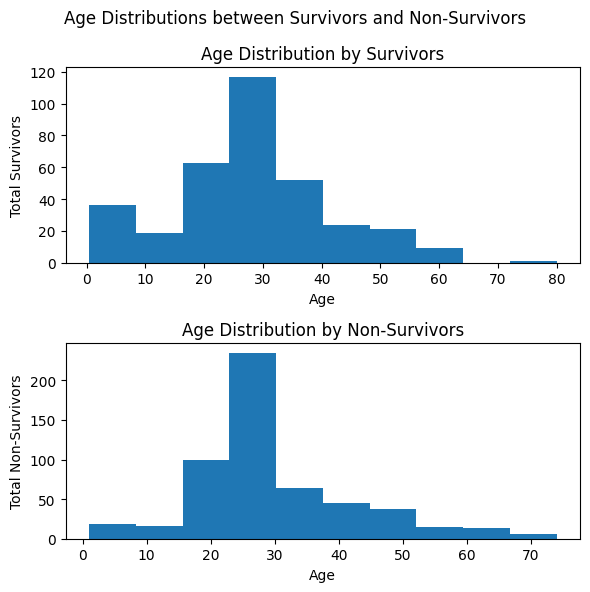

In [24]:
plt.figure(figsize=(6,6))

plt.subplot(2,1,1)
Age_survived.plot(kind='hist', label = 'Survived')
plt.xlabel('Age')
plt.ylabel('Total Survivors')
plt.title('Age Distribution by Survivors')

plt.subplot(2,1,2)
Age_not_survived.plot(kind='hist', label = 'Not Survived')
plt.xlabel('Age')
plt.ylabel('Total Non-Survivors')
plt.title('Age Distribution by Non-Survivors')

plt.suptitle('Age Distributions between Survivors and Non-Survivors')
plt.tight_layout()
plt.show()

- How is Ticket Fare distributed across classes?

In [25]:
fare_distributed = Titanic.groupby('Pclass')['Fare'].mean()
fare_distributed


Pclass
1    84.154687
2    20.662183
3    13.675550
Name: Fare, dtype: float64

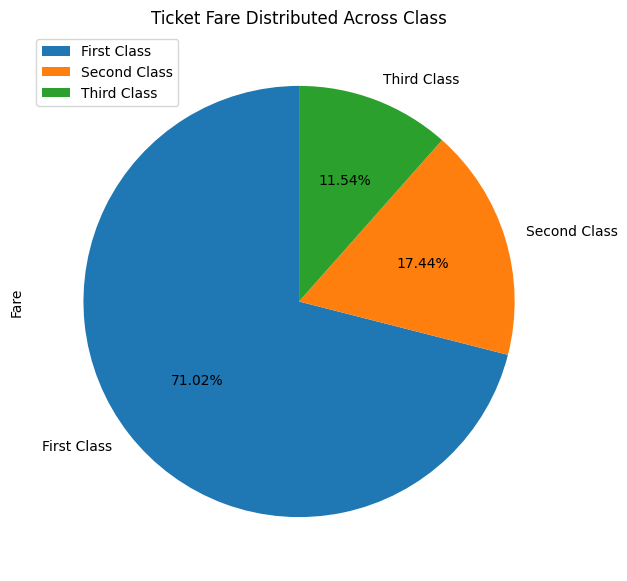

In [26]:
plt.figure(figsize=(7,7))
label = ['First Class', 'Second Class', 'Third Class']
fare_distributed.plot(kind='pie', autopct = '%1.2f%%', labels = label, startangle = 90)
plt.title('Ticket Fare Distributed Across Class')
plt.legend()
plt.show()

- Which port had more passengers? (Embarked distribution)

In [27]:
More_passengers = Titanic.groupby('Embarked')['PassengerId'].count()
More_passengers

Embarked
C    168
Q     77
S    646
Name: PassengerId, dtype: int64

<function matplotlib.pyplot.show(close=None, block=None)>

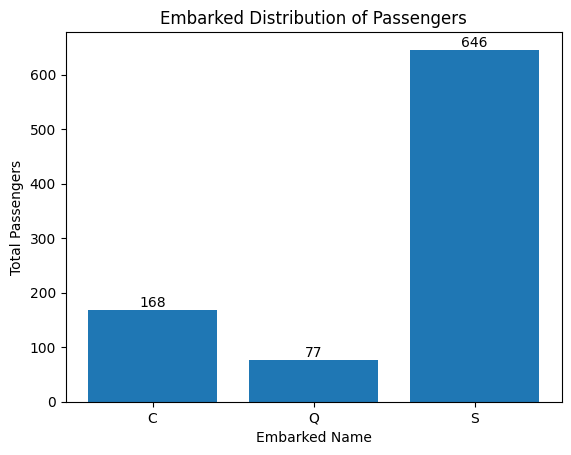

In [28]:
plt.bar(More_passengers.index, More_passengers.values)
plt.xlabel('Embarked Name')
plt.ylabel('Total Passengers')
plt.title('Embarked Distribution of Passengers')

for i, value in enumerate(More_passengers.values):
    plt.text(i, value, str(value), ha='center', va='bottom')
    
plt.show

- What is the correlation among numerical variables? (Heatmap)

In [45]:
import seaborn as sns

In [46]:
numerical_data = Titanic.select_dtypes(include=['int64', 'float64'])

corr_matrix = numerical_data.corr()

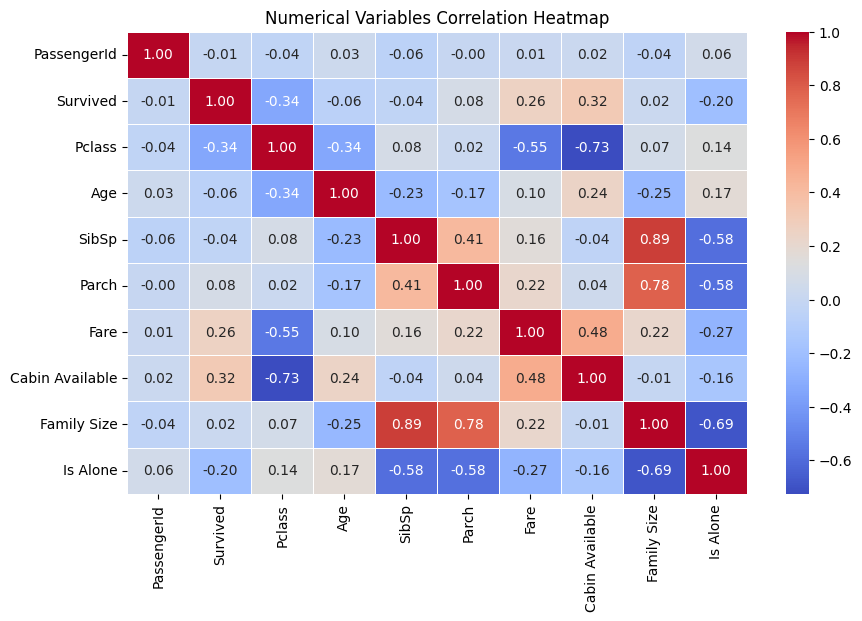

In [48]:
plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

plt.title('Numerical Variables Correlation Heatmap')
plt.show()

# annot=True → shows correlation values
# cmap='coolwarm' →
# Red = positive
# Blue = negative
# fmt='.2f' → 2 decimal places

Feature Engineering
- Create a Family Size feature and analyze survival impact.

In [30]:
Titanic['Family Size'] = Titanic['SibSp'] + Titanic['Parch'] + 1

In [31]:
family_survival = Titanic.groupby('Family Size')['Survived'].mean()*100
family_survival

Family Size
1     30.353818
2     55.279503
3     57.843137
4     72.413793
5     20.000000
6     13.636364
7     33.333333
8      0.000000
11     0.000000
Name: Survived, dtype: float64

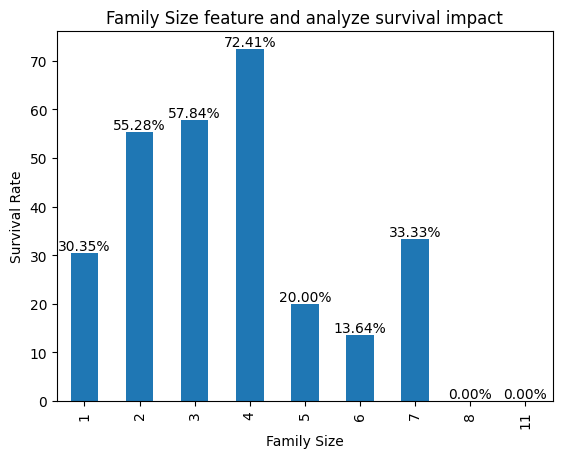

In [32]:
family_survival.plot(kind='bar')
plt.xlabel('Family Size')
plt.ylabel('Survival Rate')
plt.title('Family Size feature and analyze survival impact')

for i, value in enumerate(family_survival.values):
    plt.text(i, value, f'{value:.2f}%', ha = 'center', va = 'bottom')

plt.show()

- Create an IsAlone feature and analyze survival impact.

In [33]:
Titanic['Is Alone'] = (Titanic['Family Size'] == 1).astype(int)

In [34]:
Isalone_survival = Titanic.groupby('Is Alone')['Survived'].mean()*100
Isalone_survival

Is Alone
0    50.564972
1    30.353818
Name: Survived, dtype: float64

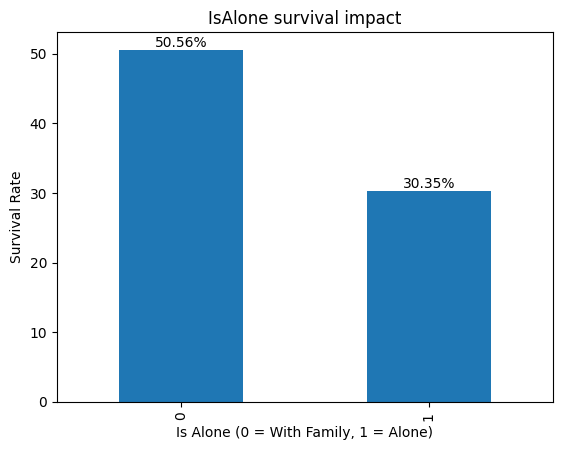

In [35]:
Isalone_survival.plot(kind='bar')
plt.xlabel('Is Alone (0 = With Family, 1 = Alone)')
plt.ylabel('Survival Rate')
plt.title('IsAlone survival impact')

for i, value in enumerate(Isalone_survival.values):
    plt.text(i, value, f'{value:.2f}%', ha = 'center', va = 'bottom')
plt.show()


- Extract Title from Name and analyze survival differences.

In [36]:
Titanic['Title'] = Titanic['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
Titanic['Title']

<>:1: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<>:1: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
C:\Users\sahay\AppData\Local\Temp\ipykernel_7176\736484447.py:1: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
  Titanic['Title'] = Titanic['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)


0        Mr
1       Mrs
2      Miss
3       Mrs
4        Mr
       ... 
886     Rev
887    Miss
888    Miss
889      Mr
890      Mr
Name: Title, Length: 891, dtype: object

In [37]:
title_survival = Titanic.groupby('Title')['Survived'].mean().sort_values(ascending=False)*100
title_survival

Title
Countess    100.000000
Ms          100.000000
Lady        100.000000
Mme         100.000000
Mlle        100.000000
Sir         100.000000
Mrs          79.200000
Miss         69.780220
Master       57.500000
Major        50.000000
Col          50.000000
Dr           42.857143
Mr           15.667311
Capt          0.000000
Don           0.000000
Jonkheer      0.000000
Rev           0.000000
Name: Survived, dtype: float64

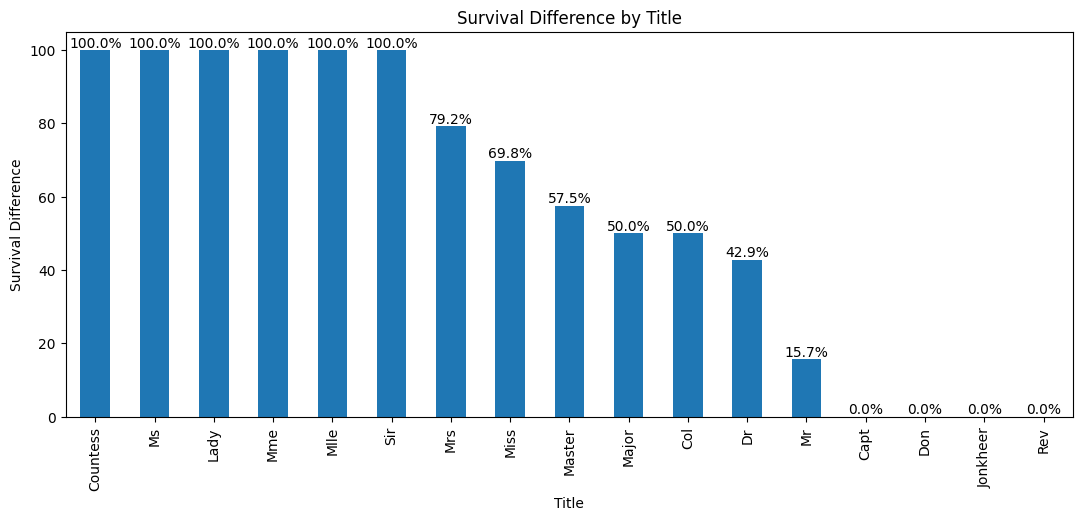

In [38]:
plt.figure(figsize=(13, 5))

title_survival.plot(kind='bar')
plt.xlabel('Title')
plt.ylabel('Survival Difference')
plt.title('Survival Difference by Title')

for i, value in enumerate(title_survival.values):
    plt.text(i, value, f'{value:.1f}%', ha = 'center', va = 'bottom')

plt.show()

- Group passengers into Age categories and analyze survival.


In [39]:
Titanic['Age Group'] = pd.cut(Titanic['Age'], 
    bins=[0,12,18,35,60,80], 
    labels=['Child','Teen','Young Adult','Adult','Senior'])

# pd.cut() Converts continuous numerical data (Age) into categories
# bins - range 

In [40]:
agegroup_survival = Titanic.groupby('Age Group')['Survived'].mean()*100
agegroup_survival

C:\Users\sahay\AppData\Local\Temp\ipykernel_7176\1827369890.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agegroup_survival = Titanic.groupby('Age Group')['Survived'].mean()*100


Age Group
Child          57.971014
Teen           42.857143
Young Adult    35.327103
Adult          40.000000
Senior         22.727273
Name: Survived, dtype: float64

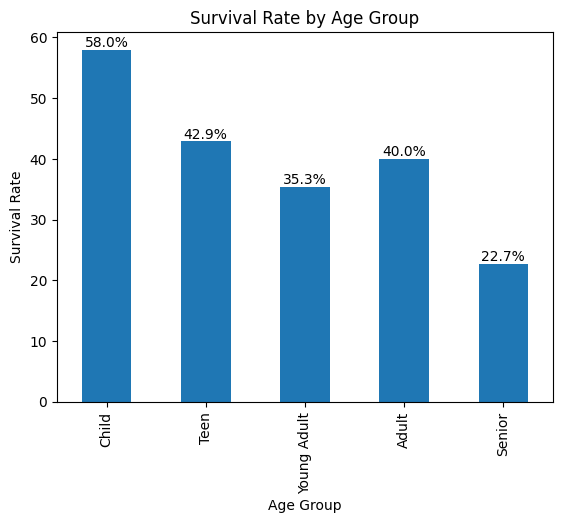

In [41]:
agegroup_survival.plot(kind='bar')
plt.xlabel('Age Group')
plt.ylabel('Survival Rate')
plt.title('Survival Rate by Age Group')

for i, value in enumerate(agegroup_survival.values):
    plt.text(i, value, f'{value:.1f}%', ha = 'center', va = 'bottom')
    
plt.show()

In [42]:
Titanic.head(20)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Cabin Available,Family Size,Is Alone,Title,Age Group
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,0,2,0,Mr,Young Adult
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,1,2,0,Mrs,Adult
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,0,1,1,Miss,Young Adult
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,1,2,0,Mrs,Young Adult
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,0,1,1,Mr,Young Adult
5,6,0,3,"Moran, Mr. James",male,28.0,0,0,330877,8.4583,Q,0,1,1,Mr,Young Adult
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,S,1,1,1,Mr,Adult
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,S,0,5,0,Master,Child
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,S,0,3,0,Mrs,Young Adult
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,C,0,2,0,Mrs,Teen


In [43]:
Titanic.to_csv('Titanic Cleaned.csv', index=False)